In [1]:
import sys
sys.path.append("../..")

import numpy as np
import csv
import torch
import torch.nn.functional as F
from monai import transforms
from monai.data import CacheDataset, DataLoader, ThreadDataLoader
from monai.data.utils import pad_list_data_collate
from torch.amp import GradScaler, autocast
from tqdm import tqdm
import random
import yaml

import utils.custom_transforms as custom_transforms

from spark.Spark_2D import SparK_2D 

/home/fehrdelt/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
Importing from timm.models.layers is deprecated, please import via timm.layers


`pip install timm`

In [2]:
ROOT_DIR = "/home/fehrdelt/bettik/"
#ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

# Guided reconstruction with conditioned diffusion models for unsupervised anomaly detection in brain MRIs

https://www.sciencedirect.com/science/article/pii/S0010482525000101

https://github.com/FinnBehrendt/Conditioned-Diffusion-Models-UAD

### Encoder conditioner : patch training from Spark2D autoencoder (Designing BERT for Convolutional Networks: Sparse and Hierarchical Masked Modeling)


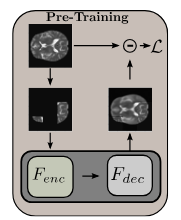

In [3]:
# Load the YAML file
with open(f'{ROOT_DIR}/AnoDiffExperiments/spark/2d_ddpm_cond_spark.yaml', 'r') as file:
    cfg = yaml.safe_load(file)

In [4]:
model = SparK_2D(cfg)

[sparse_cnn] model kwargs={'drop_path_rate': 0.05, 'pretrained': False, 'num_classes': 0, 'global_pool': ''}
[mid, py=4][edl 0]: k=1, #para = 1.05
[mid, py=4][edl 1]: k=3, #para = 2.36
[mid, py=4][edl 2]: k=3, #para = 0.59
[mid, py=4][edl 3]: k=3, #para = 0.15
[mid, py=4][mask_tokens]: (2048, 1024, 512, 256)
